# RQ1 Results Comparison: Original vs. Replicated

This notebook compares the confusion matrices and classification metrics from the original authors' runs (`console.out`) against our replication (`CX_rep_console.out`) for all 8 configurations (C1–C8).

## How to Read the Confusion Matrix

For a binary classifier like GPTSniffer, the confusion matrix is a 2×2 grid:

```
                  Predicted: ChatGPT   Predicted: Human
Actual: ChatGPT        TP                   FN
Actual: Human          FP                   TN
```

- **TP (True Positive):** ChatGPT code correctly detected as ChatGPT
- **TN (True Negative):** Human code correctly identified as Human
- **FP (False Positive):** Human code wrongly flagged as ChatGPT (accusing a student unfairly)
- **FN (False Negative):** ChatGPT code that slipped through undetected

**In this context, FN is the most costly error** — it means the detector failed to catch AI-generated code.

### Key metrics derived from the matrix

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Precision** (ChatGPT) | TP / (TP + FP) | Of all flagged-as-ChatGPT, how many were actually ChatGPT? |
| **Recall** (ChatGPT) | TP / (TP + FN) | Of all actual ChatGPT files, how many were caught? |
| **F1-score** | 2 × P × R / (P + R) | Harmonic mean of precision and recall |
| **Accuracy** | (TP + TN) / Total | Overall fraction of correct predictions |

> **Note:** The console.out files print "Normalized confusion matrix" but only log the classification report numbers. We reconstruct the raw counts from `recall x support` (e.g., if recall=0.99 and support=148, then TP = round(0.99 × 148) = 147).

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
def parse_classification_report(text):
    """
    Extracts precision, recall, f1, support for ChatGPT and Human classes,
    plus overall accuracy, from a sklearn classification_report string.
    Returns a dict or None if not found.
    """
    # Match rows like:  ChatGPT   0.90   0.99   0.94   148
    row_pattern = re.compile(
        r'^\s*(ChatGPT|Human)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)',
        re.MULTILINE
    )
    acc_pattern = re.compile(r'accuracy\s+([0-9.]+)\s+(\d+)', re.MULTILINE)

    rows = {m.group(1): {
        'precision': float(m.group(2)),
        'recall':    float(m.group(3)),
        'f1':        float(m.group(4)),
        'support':   int(m.group(5)),
    } for m in row_pattern.finditer(text)}

    acc_match = acc_pattern.search(text)
    if not rows or not acc_match:
        return None

    rows['accuracy'] = float(acc_match.group(1))
    rows['total'] = int(acc_match.group(2))
    return rows


def reconstruct_cm(report):
    """
    Reconstructs the 2x2 confusion matrix from recall and support.
    Rows = Actual, Cols = Predicted.  Order: [ChatGPT, Human]
    """
    tp_chatgpt = round(report['ChatGPT']['recall'] * report['ChatGPT']['support'])
    fn_chatgpt = report['ChatGPT']['support'] - tp_chatgpt   # ChatGPT predicted as Human

    tp_human   = round(report['Human']['recall'] * report['Human']['support'])
    fp_human   = report['Human']['support'] - tp_human       # Human predicted as ChatGPT

    return np.array([[tp_chatgpt, fn_chatgpt],
                     [fp_human,   tp_human]])


BASE = Path('.')  # run from DATASETS/RQ1/
configs = [f'C{i}' for i in range(1, 9)]

results = {}
for c in configs:
    orig_path = BASE / c / 'console.out'
    rep_path  = BASE / c / f'{c}_rep_console.out'

    orig_text = orig_path.read_text(errors='ignore')
    rep_text  = rep_path.read_text(errors='ignore')

    orig_report = parse_classification_report(orig_text)
    rep_report  = parse_classification_report(rep_text)

    results[c] = {
        'original':   {'report': orig_report, 'cm': reconstruct_cm(orig_report)},
        'replicated': {'report': rep_report,  'cm': reconstruct_cm(rep_report)},
    }

print('Parsed configurations:', list(results.keys()))

Parsed configurations: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']


## Side-by-Side Confusion Matrices

Each pair shows the original (left) and replicated (right) confusion matrix for the same configuration.

- Rows = **actual** class, Columns = **predicted** class
- Diagonal cells (top-left, bottom-right) = correct predictions — **darker is better**
- Off-diagonal cells = errors — **lighter is better**
- Numbers show raw counts; color intensity shows the proportion within each row (normalized by row = recall per class)

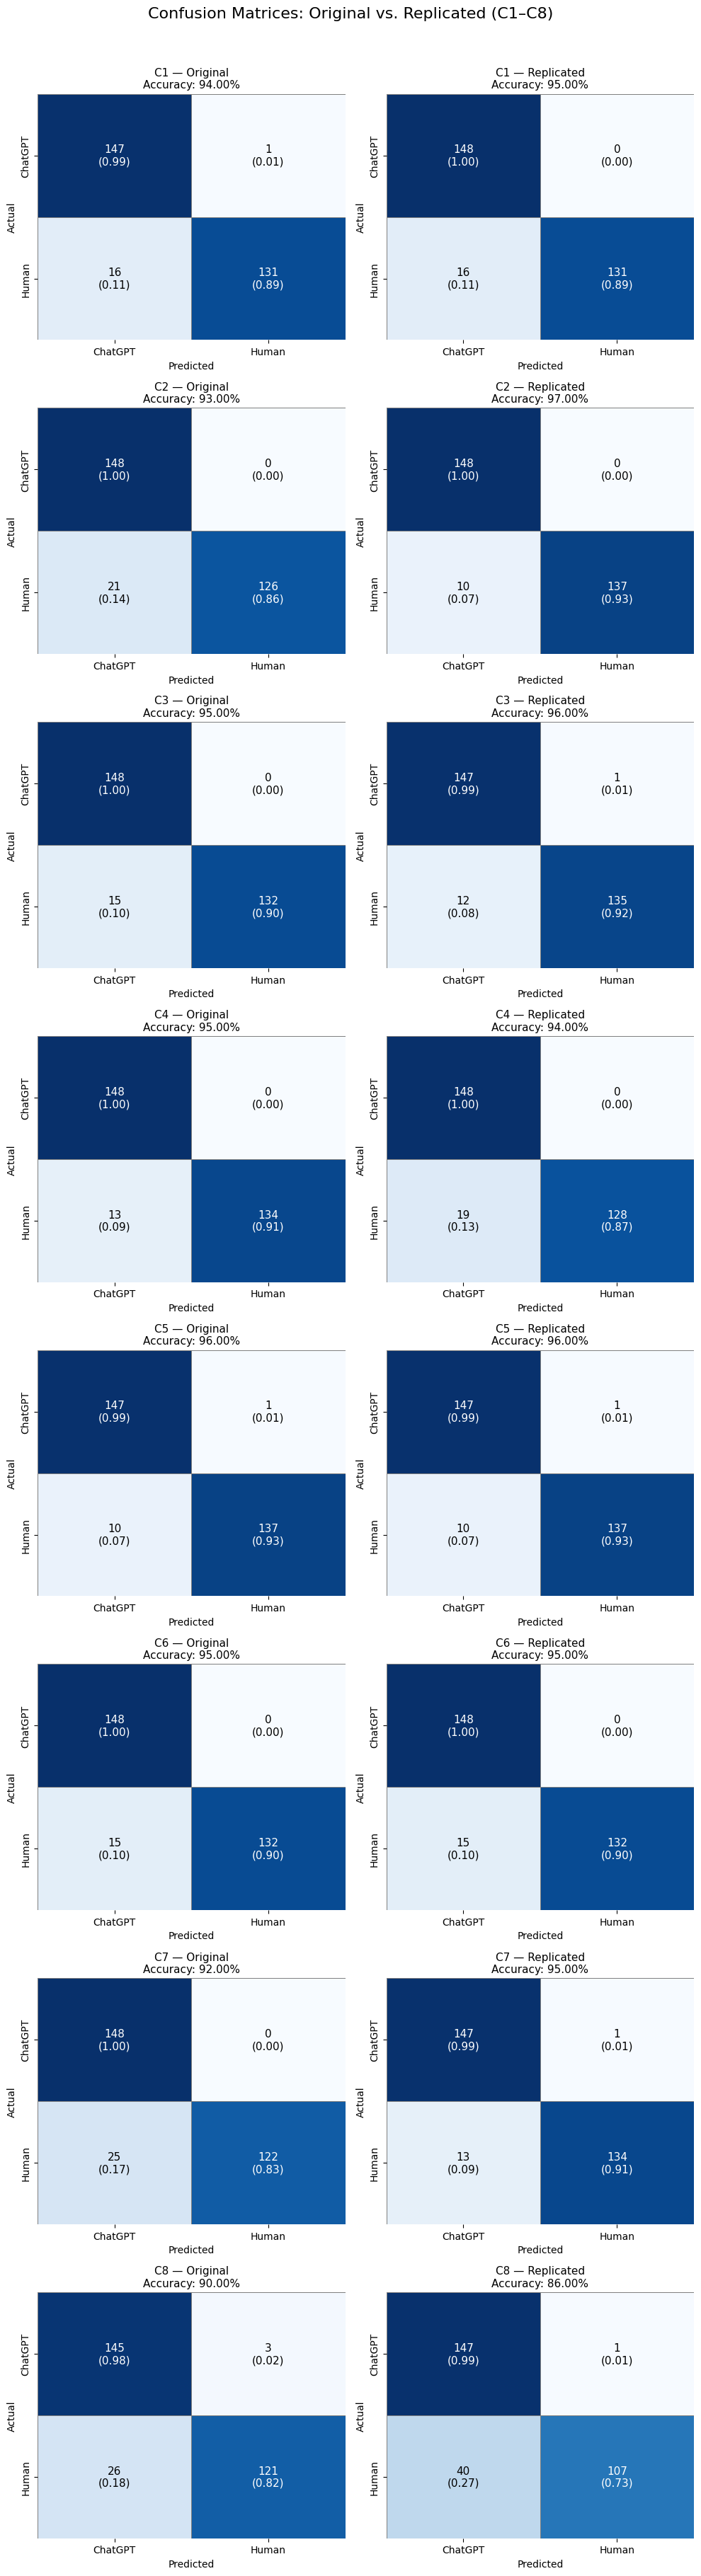

Saved to confusion_matrices_comparison.png


In [3]:
labels = ['ChatGPT', 'Human']

fig, axes = plt.subplots(8, 2, figsize=(10, 36))
fig.suptitle('Confusion Matrices: Original vs. Replicated (C1–C8)', fontsize=16, y=1.01)

for row_idx, c in enumerate(configs):
    for col_idx, run in enumerate(['original', 'replicated']):
        ax = axes[row_idx][col_idx]
        cm = results[c][run]['cm']
        report = results[c][run]['report']

        # Normalize by row so color shows recall per class
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=1, ax=ax, cbar=False,
            linewidths=0.5, linecolor='gray'
        )

        # Annotate with raw counts + normalized value
        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.6 else 'black'
                ax.text(j + 0.5, i + 0.5,
                        f'{cm[i,j]}\n({cm_norm[i,j]:.2f})',
                        ha='center', va='center', fontsize=11, color=color)

        acc = report['accuracy']
        ax.set_title(f'{c} — {run.capitalize()}\nAccuracy: {acc:.2%}', fontsize=11)
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to confusion_matrices_comparison.png')

## Summary Table: Accuracy and F1 Across All Configurations

In [4]:
rows = []
for c in configs:
    for run in ['original', 'replicated']:
        r = results[c][run]['report']
        cm = results[c][run]['cm']
        fp = cm[1, 0]  # Human predicted as ChatGPT
        fn = cm[0, 1]  # ChatGPT predicted as Human
        rows.append({
            'Config': c,
            'Run': run.capitalize(),
            'Accuracy': f"{r['accuracy']:.2%}",
            'F1 ChatGPT': f"{r['ChatGPT']['f1']:.2f}",
            'F1 Human': f"{r['Human']['f1']:.2f}",
            'Macro F1': f"{(r['ChatGPT']['f1'] + r['Human']['f1']) / 2:.2f}",
            'FP (Human→ChatGPT)': fp,
            'FN (ChatGPT→Human)': fn,
        })

df = pd.DataFrame(rows)
df_display = df.set_index(['Config', 'Run'])
df_display.style.set_caption('Classification Results Summary')

## Accuracy Comparison Chart

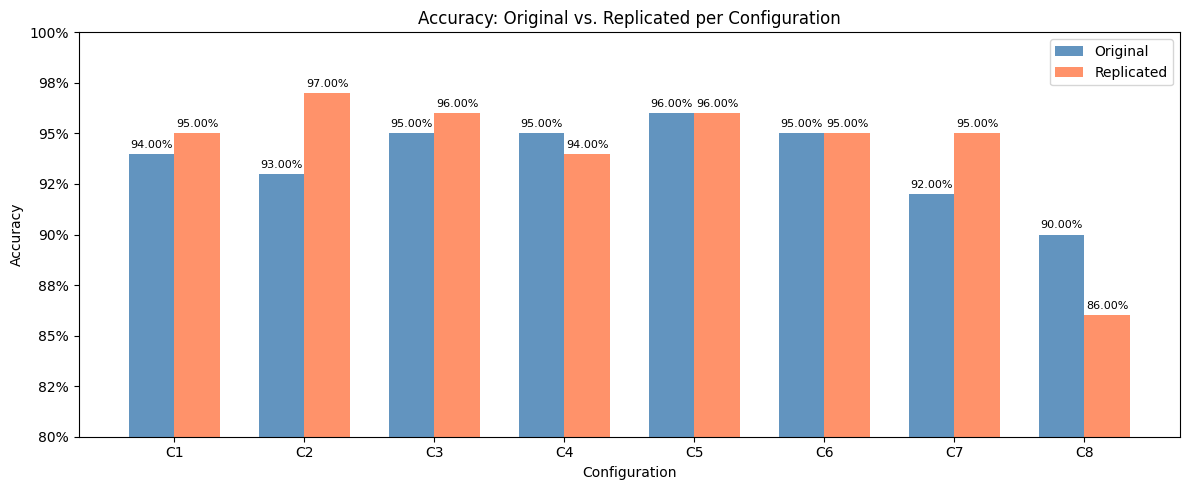

In [5]:
orig_acc = [results[c]['original']['report']['accuracy'] for c in configs]
rep_acc  = [results[c]['replicated']['report']['accuracy'] for c in configs]

x = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, orig_acc, width, label='Original', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, rep_acc,  width, label='Replicated', color='coral', alpha=0.85)

ax.set_xlabel('Configuration')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Original vs. Replicated per Configuration')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.set_ylim(0.80, 1.00)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Annotate bars with values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## False Negative Analysis

FN = ChatGPT files that were **not detected** (slipped through as Human). This is the most important error type for the plagiarism detection use case.

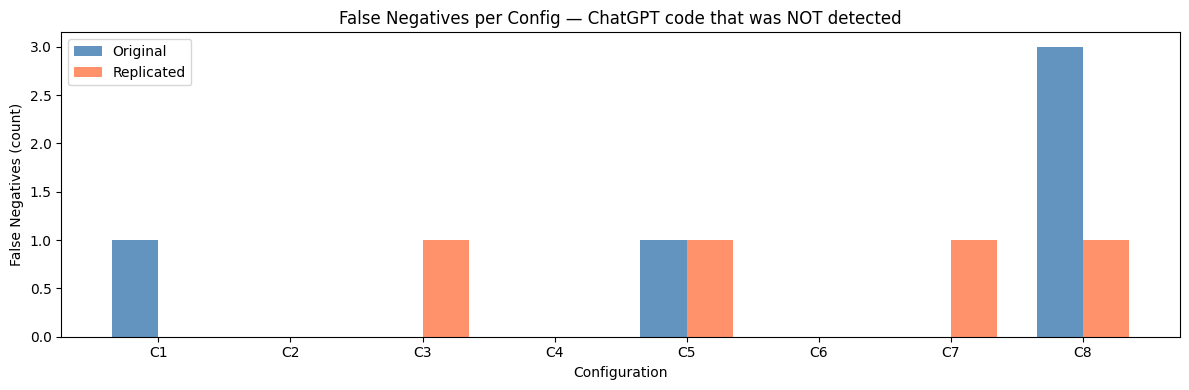

In [6]:
orig_fn = [results[c]['original']['cm'][0, 1] for c in configs]
rep_fn  = [results[c]['replicated']['cm'][0, 1] for c in configs]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, orig_fn, width, label='Original',   color='steelblue', alpha=0.85)
ax.bar(x + width/2, rep_fn,  width, label='Replicated', color='coral',     alpha=0.85)

ax.set_xlabel('Configuration')
ax.set_ylabel('False Negatives (count)')
ax.set_title('False Negatives per Config — ChatGPT code that was NOT detected')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()

plt.tight_layout()
plt.savefig('false_negatives_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights

In [7]:
print('=' * 60)
print('REPLICATION INSIGHTS')
print('=' * 60)

deltas = {}
for c in configs:
    o = results[c]['original']['report']['accuracy']
    r = results[c]['replicated']['report']['accuracy']
    deltas[c] = r - o

print('\nAccuracy delta (Replicated − Original):')
for c, d in deltas.items():
    direction = '↑ better' if d > 0 else ('↓ worse' if d < 0 else '= identical')
    print(f'  {c}: {d:+.2%}  {direction}')

improved = [c for c, d in deltas.items() if d > 0]
worsened = [c for c, d in deltas.items() if d < 0]
same     = [c for c, d in deltas.items() if d == 0]

print(f'\nSummary: {len(improved)} improved, {len(worsened)} worse, {len(same)} identical')
if improved: print(f'  Improved: {improved}')
if worsened: print(f'  Worse:    {worsened}')
if same:     print(f'  Identical:{same}')

print('\nFalse Negative comparison (lower = better — fewer undetected ChatGPT files):')
for c in configs:
    o_fn = results[c]['original']['cm'][0, 1]
    r_fn = results[c]['replicated']['cm'][0, 1]
    diff = r_fn - o_fn
    direction = '↑ more missed' if diff > 0 else ('↓ fewer missed' if diff < 0 else '= same')
    print(f'  {c}: original={o_fn}, replicated={r_fn}  {direction}')

print()
print('NOTE: Small differences (~1-2%) are expected due to non-determinism')
print('in training (random weight initialization, data shuffling). The')
print('replication is considered successful if results are within ~2% of')
print('the originals across all configurations.')

REPLICATION INSIGHTS

Accuracy delta (Replicated − Original):
  C1: +1.00%  ↑ better
  C2: +4.00%  ↑ better
  C3: +1.00%  ↑ better
  C4: -1.00%  ↓ worse
  C5: +0.00%  = identical
  C6: +0.00%  = identical
  C7: +3.00%  ↑ better
  C8: -4.00%  ↓ worse

Summary: 4 improved, 2 worse, 2 identical
  Improved: ['C1', 'C2', 'C3', 'C7']
  Worse:    ['C4', 'C8']
  Identical:['C5', 'C6']

False Negative comparison (lower = better — fewer undetected ChatGPT files):
  C1: original=1, replicated=0  ↓ fewer missed
  C2: original=0, replicated=0  = same
  C3: original=0, replicated=1  ↑ more missed
  C4: original=0, replicated=0  = same
  C5: original=1, replicated=1  = same
  C6: original=0, replicated=0  = same
  C7: original=0, replicated=1  ↑ more missed
  C8: original=3, replicated=1  ↓ fewer missed

NOTE: Small differences (~1-2%) are expected due to non-determinism
in training (random weight initialization, data shuffling). The
replication is considered successful if results are within ~2% of
t